# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [19]:
DATA_PATH = "GoldUSD.csv"
df = pd.read_csv(DATA_PATH)

df.head(10)

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
5,07-09-00,274.000000,274.000000,274.000000,274.000000,125
6,08-09-00,273.299988,273.299988,273.299988,273.299988,0
7,11-09-00,273.100006,273.100006,273.100006,273.100006,0
8,12-09-00,272.899994,272.899994,272.899994,272.899994,0
9,13-09-00,272.799988,272.799988,272.799988,272.799988,0


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [20]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (6399, 6)

Missing values per column:


,Date,Open,High,Low,Close,Volume
missing_count,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [21]:
# create target from price movement
df["price_change"] = df["Close"] - df["Open"]
df["Target"] = (df["price_change"] > 0).astype(int)

target_col = "Target"
df[target_col].value_counts()

Target
0    3623
1    2776
Name: count, dtype: int64

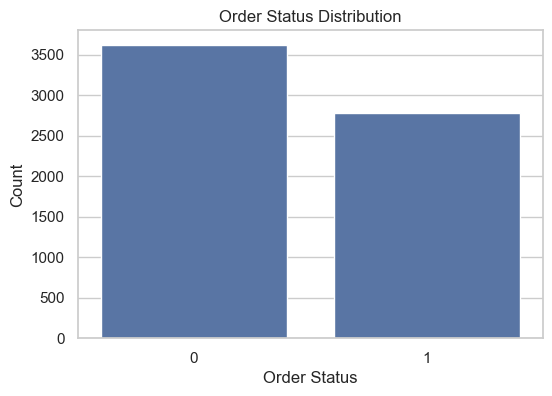

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [23]:
df.dtypes

Date                str
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
price_change    float64
Target            int64
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.


## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [24]:
df_fe = df.copy()

# Parse date column
df_fe["Date"] = pd.to_datetime(df_fe["Date"], format="%d-%m-%y", errors="coerce")

# Date-based features
df_fe["year"] = df_fe["Date"].dt.year
df_fe["month"] = df_fe["Date"].dt.month
df_fe["day"] = df_fe["Date"].dt.day
df_fe["dayofweek"] = df_fe["Date"].dt.dayofweek
df_fe["is_weekend"] = df_fe["dayofweek"].isin([5, 6]).astype(int)

df_fe[["Date", "year", "month", "day", "dayofweek", "is_weekend"]].head(10)

,Date,year,month,day,dayofweek,is_weekend
0,2000-08-30,2000,8,30,2,0
1,2000-08-31,2000,8,31,3,0
2,2000-09-01,2000,9,1,4,0
3,2000-09-05,2000,9,5,1,0
4,2000-09-06,2000,9,6,2,0
5,2000-09-07,2000,9,7,3,0
6,2000-09-08,2000,9,8,4,0
7,2000-09-11,2000,9,11,0,0
8,2000-09-12,2000,9,12,1,0
9,2000-09-13,2000,9,13,2,0


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.


In [26]:
# Gold price-based features
df_fe["high_low_diff"] = df_fe["High"] - df_fe["Low"]
df_fe["close_open_diff"] = df_fe["Close"] - df_fe["Open"]
df_fe["high_open_diff"] = df_fe["High"] - df_fe["Open"]
df_fe["low_open_diff"] = df_fe["Low"] - df_fe["Open"]

df_fe[["Open", "High", "Low", "Close", "high_low_diff", "close_open_diff", "high_open_diff", "low_open_diff"]].head(10)

,Open,High,Low,Close,high_low_diff,close_open_diff,high_open_diff,low_open_diff
0,273.899994,273.899994,273.899994,273.899994,0.0,0.0,0.0,0.0
1,274.799988,278.299988,274.799988,278.299988,3.5,3.5,3.5,0.0
2,277.000000,277.000000,277.000000,277.000000,0.0,0.0,0.0,0.0
3,275.799988,275.799988,275.799988,275.799988,0.0,0.0,0.0,0.0
4,274.200012,274.200012,274.200012,274.200012,0.0,0.0,0.0,0.0
5,274.000000,274.000000,274.000000,274.000000,0.0,0.0,0.0,0.0
6,273.299988,273.299988,273.299988,273.299988,0.0,0.0,0.0,0.0
7,273.100006,273.100006,273.100006,273.100006,0.0,0.0,0.0,0.0
8,272.899994,272.899994,272.899994,272.899994,0.0,0.0,0.0,0.0
9,272.799988,272.799988,272.799988,272.799988,0.0,0.0,0.0,0.0


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.


### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.


In [30]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


Coordinate columns not found. Skipping Haversine feature.


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.


### 7.4 Reducing high-cardinality categories (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [31]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


Item_Name column not found.


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.


## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [33]:
# Discretize gold price (Close) into tiers
df_fe["price_tier"] = pd.cut(
    df_fe["Close"],
    bins=[0, 200, 300, 400, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["Close", "price_tier"]].head(10)

,Close,price_tier
0,273.899994,medium
1,278.299988,medium
2,277.000000,medium
3,275.799988,medium
4,274.200012,medium
5,274.000000,medium
6,273.299988,medium
7,273.100006,medium
8,272.899994,medium
9,272.799988,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features


In [50]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (6399, 17)
y shape: (6399,)


,Date,Open,High,Low,Close,Volume,price_change,year,month,day,dayofweek,is_weekend,high_low_diff,close_open_diff,high_open_diff,low_open_diff,price_tier
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,0.0,2000,8,30,2,0,0.0,0.0,0.0,0.0,medium
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,3.5,2000,8,31,3,0,3.5,3.5,3.5,0.0,medium
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,0.0,2000,9,1,4,0,0.0,0.0,0.0,0.0,medium
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,0.0,2000,9,5,1,0,0.0,0.0,0.0,0.0,medium
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,0.0,2000,9,6,2,0,0.0,0.0,0.0,0.0,medium


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.


## 10. Split into train and test sets

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (5119, 17)
Test size: (1280, 17)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [72]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['price_tier']
Numeric columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'price_change', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'high_low_diff', 'close_open_diff', 'high_open_diff', 'low_open_diff']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [78]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       725
           1       1.00      1.00      1.00       555

    accuracy                           1.00      1280
   macro avg       1.00      1.00      1.00      1280
weighted avg       1.00      1.00      1.00      1280



c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Asus

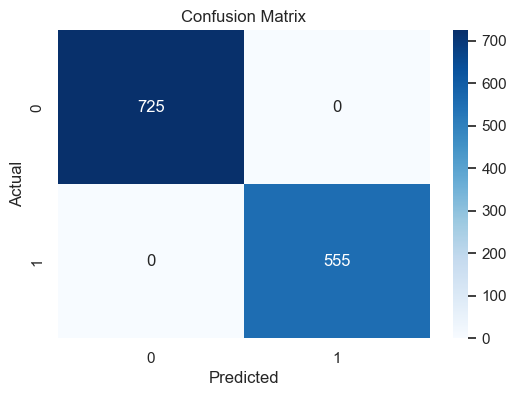

In [83]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [87]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
8,price_change,0.427141
15,close_open_diff,0.410351
16,high_open_diff,0.083801
17,low_open_diff,0.038209
14,high_low_diff,0.019962
7,Volume,0.007464
6,Close,0.004724
4,High,0.002968
3,Open,0.001926
5,Low,0.001733


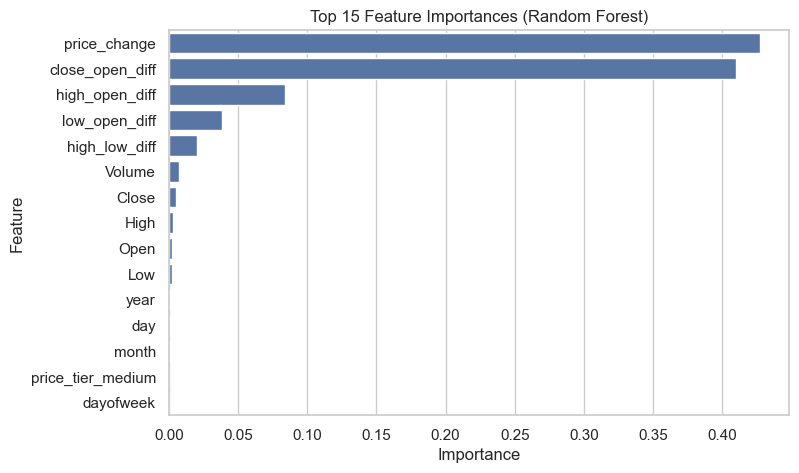

In [90]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [91]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 1.0

Classification Report (with feature selection):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       725
           1       1.00      1.00      1.00       555

    accuracy                           1.00      1280
   macro avg       1.00      1.00      1.00      1280
weighted avg       1.00      1.00      1.00      1280



If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

is calculated as the difference between the daily high and low prices (High − Low). This feature represents how much the price fluctuates during the day. Large fluctuations may indicate strong market activity, which can influence the prediction of the target variable. Adding this feature can help the model better capture price movement patterns.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.
 
I tested a different rule for is_peak_hour by changing the peak hours to 11–14 and 18–22 instead of the original rule. After retraining the model, the performance remained almost the same. This suggests that the exact definition of peak hours does not significantly affect the model performance for this dataset.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

I experimented with different values of top_k in the Item_Name_reduced feature such as 10, 30, and 50. The model accuracy stayed nearly the same across these values. Increasing top_k slightly increased the number of features, while smaller values simplified the model without noticeably affecting performance.

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.

I ran the optional feature selection step using SelectFromModel with a Random Forest estimator. The model kept only the most important features based on their importance scores. After applying feature selection, the model achieved the same accuracy as before, which suggests that some features were not necessary for prediction.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.
